<a href="https://colab.research.google.com/github/cataiap/Challenger-Telecom-2/blob/main/Challenger_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Extracción del Archivo Tratado

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/cataiap/Challenger-Telecom-2/main/datos_tratados_telecomx.csv"
df = pd.read_csv(url)

df.head()

,customerID,Churn,Churn_bin,gender,SeniorCitizen,Partner,Dependents,tenure,Partner_bin,Dependents_bin,...,TechSupport_bin,StreamingTV_bin,StreamingMovies_bin,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,PaperlessBilling_bin
0,0002-ORFBO,No,0,Female,0,Yes,Yes,9,1,1,...,1,1,0,One year,Yes,Mailed check,65.6,593.30,2.186667,1
1,0003-MKNFE,No,0,Male,0,No,No,9,0,0,...,0,0,1,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0
2,0004-TLHLJ,Yes,1,Male,0,No,No,4,0,0,...,0,0,0,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,Yes,1,Male,1,Yes,No,13,1,0,...,0,1,1,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1
4,0013-EXCHZ,Yes,1,Female,1,Yes,No,3,1,0,...,1,1,0,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1


In [3]:
df.shape

(7043, 34)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   Churn                 7043 non-null   object 
 2   Churn_bin             7043 non-null   int64  
 3   gender                7043 non-null   object 
 4   SeniorCitizen         7043 non-null   int64  
 5   Partner               7043 non-null   object 
 6   Dependents            7043 non-null   object 
 7   tenure                7043 non-null   int64  
 8   Partner_bin           7043 non-null   int64  
 9   Dependents_bin        7043 non-null   int64  
 10  PhoneService          7043 non-null   object 
 11  MultipleLines         7043 non-null   object 
 12  PhoneService_bin      7043 non-null   int64  
 13  MultipleLines_bin     7043 non-null   int64  
 14  InternetService       7043 non-null   object 
 15  OnlineSecurity       

# 2. Eliminación de Columnas Irrelevantes

In [5]:
# Hacemos una copia del dataset original para trabajar una versión específica para modelado
# Así no modificamos el DataFrame base y mantenemos una versión de referencia intacta
df_modelo = df.copy()

# Definimos la variable objetivo del modelo
# Churn_bin ya está en formato numérico:
# 1 = cliente canceló
# 0 = cliente no canceló
y = df_modelo["Churn_bin"]

# Lista de columnas en texto que tienen una versión binaria equivalente
# Estas columnas se eliminarán del dataset de modelado para evitar duplicar información
columnas_texto_redundantes = [
    "Churn",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

# Además eliminamos customerID porque es solo un identificador único
# No aporta valor predictivo al modelo
columnas_a_eliminar = ["customerID"] + columnas_texto_redundantes + ["Churn_bin"]

# Creamos la matriz de variables predictoras
# Aquí dejamos fuera el ID, la variable objetivo y las columnas texto duplicadas
X = df_modelo.drop(columns=columnas_a_eliminar)

# Revisamos las primeras filas para validar cómo quedó el dataset de modelado
X.head()

,gender,SeniorCitizen,tenure,Partner_bin,Dependents_bin,PhoneService_bin,MultipleLines_bin,InternetService,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,StreamingTV_bin,StreamingMovies_bin,Contract,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,PaperlessBilling_bin
0,Female,0,9,1,1,1,0,DSL,0,1,0,1,1,0,One year,Mailed check,65.6,593.30,2.186667,1
1,Male,0,9,0,0,1,1,DSL,0,0,0,0,0,1,Month-to-month,Mailed check,59.9,542.40,1.996667,0
2,Male,0,4,0,0,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,Electronic check,73.9,280.85,2.463333,1
3,Male,1,13,1,0,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,Electronic check,98.0,1237.85,3.266667,1
4,Female,1,3,1,0,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,Mailed check,83.9,267.40,2.796667,1


In [6]:
# Revisamos el tamaño de la matriz de variables predictoras y de la variable objetivo
# X contiene las variables que usará el modelo
# y contiene la respuesta correcta que el modelo intentará predecir
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7043, 20)
Dimensiones de y: (7043,)


In [7]:
# Mostramos las columnas finales que quedaron en el dataset de modelado
# Esto nos ayuda a confirmar que sí eliminamos las columnas redundantes
X.columns.tolist()

['gender',
 'SeniorCitizen',
 'tenure',
 'Partner_bin',
 'Dependents_bin',
 'PhoneService_bin',
 'MultipleLines_bin',
 'InternetService',
 'OnlineSecurity_bin',
 'OnlineBackup_bin',
 'DeviceProtection_bin',
 'TechSupport_bin',
 'StreamingTV_bin',
 'StreamingMovies_bin',
 'Contract',
 'PaymentMethod',
 'Charges.Monthly',
 'Charges.Total',
 'Cuentas_Diarias',
 'PaperlessBilling_bin']

In [8]:
# Verificamos que las columnas irrelevantes o redundantes ya no estén en X
# Esto confirma que el dataset de modelado quedó limpio para los siguientes pasos
columnas_que_no_deben_estar = [
    "customerID", "Churn", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling", "Churn_bin"
]

# Mostramos cuáles de esas columnas siguen presentes en X
# Si el resultado es una lista vacía [], entonces la eliminación fue correcta
[col for col in columnas_que_no_deben_estar if col in X.columns]

[]

Conclusión del paso 2:
Se construyó correctamente el dataset de modelado, eliminando columnas irrelevantes o redundantes como customerID, Churn y variables categóricas de texto que ya tenían su versión binaria. La variable objetivo quedó definida como Churn_bin, mientras que X conserva únicamente las variables predictoras relevantes para las siguientes etapas del análisis.

# 3. Encoding
Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:
Artículo en Alura sobre codificación categórica

https://charitelc.com/match-3719/79715/377300512/1773092281/mf_d6555579-dc3b-4df9-be33-df0c5bf534ee/YXBpeDA3LWZhbHRhLWxpbmsuY29tfEhHSUJDSzdCSlM2OE1VWFMxUElCU0kwNHwyMDk=/feed

In [9]:
# Revisamos qué columnas de X siguen en formato texto (object)
# Estas son las variables que aún necesitan encoding para poder usarse en modelos
columnas_categoricas = X.select_dtypes(include="object").columns.tolist()

# Mostramos la lista de columnas categóricas detectadas
columnas_categoricas

['gender', 'InternetService', 'Contract', 'PaymentMethod']

In [10]:
# Aplicamos one-hot encoding a las columnas categóricas
# pd.get_dummies transforma cada categoría en una columna binaria (0 o 1)
# dtype=int se usa para que el resultado quede como enteros y sea más claro de leer
X_encoded = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    dtype=int
)

# Mostramos las primeras filas del nuevo dataset codificado
X_encoded.head()

,SeniorCitizen,tenure,Partner_bin,Dependents_bin,PhoneService_bin,MultipleLines_bin,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,1,1,1,0,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
1,0,9,0,0,1,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,0,4,0,0,1,0,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3,1,13,1,0,1,0,0,1,1,0,...,0,1,0,1,0,0,0,0,1,0
4,1,3,1,0,1,0,0,0,0,1,...,0,1,0,1,0,0,0,0,0,1


In [11]:
# Comparamos el tamaño de X antes y después del encoding
# La cantidad de filas debe mantenerse igual
# La cantidad de columnas normalmente aumenta, porque una columna categórica
# se transforma en varias columnas binarias
print("Dimensiones de X antes del encoding:", X.shape)
print("Dimensiones de X después del encoding:", X_encoded.shape)

Dimensiones de X antes del encoding: (7043, 20)
Dimensiones de X después del encoding: (7043, 28)


In [12]:
# Revisamos la estructura del dataset codificado
# Después del encoding, idealmente ya no deberían quedar columnas tipo object
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   Partner_bin                              7043 non-null   int64  
 3   Dependents_bin                           7043 non-null   int64  
 4   PhoneService_bin                         7043 non-null   int64  
 5   MultipleLines_bin                        7043 non-null   int64  
 6   OnlineSecurity_bin                       7043 non-null   int64  
 7   OnlineBackup_bin                         7043 non-null   int64  
 8   DeviceProtection_bin                     7043 non-null   int64  
 9   TechSupport_bin                          7043 non-null   int64  
 10  StreamingTV_bin                          7043 no

In [13]:
# Verificamos si aún quedan columnas en formato texto dentro de X_encoded
# Si el resultado es una lista vacía, el encoding se realizó correctamente
X_encoded.select_dtypes(include="object").columns.tolist()

[]

In [14]:
# Guardamos X_encoded como la nueva matriz principal de variables predictoras
# Desde este punto, X será la versión final codificada y lista para modelado
X = X_encoded.copy()

# Verificamos las dimensiones finales de X y de la variable objetivo y
print("Dimensiones finales de X:", X.shape)
print("Dimensiones finales de y:", y.shape)

Dimensiones finales de X: (7043, 28)
Dimensiones finales de y: (7043,)


Conclusión del paso 3:
Se aplicó correctamente one-hot encoding a las variables categóricas restantes (gender, InternetService, Contract y PaymentMethod) utilizando pd.get_dummies(). El dataset resultante conserva los 7043 registros y queda completamente en formato numérico, listo para las siguientes etapas del modelado.

# 4. Verificación de la Proporción de Cancelación (Churn)
Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html

In [15]:
# Contamos cuántos clientes hay en cada clase de la variable objetivo
# 0 = cliente que no canceló
# 1 = cliente que sí canceló
conteo_churn = y.value_counts()

# Mostramos el resultado
conteo_churn

,count
Churn_bin,
0,5174
1,1869


In [16]:
# Calculamos la proporción de cada clase
# normalize=True hace que pandas entregue proporciones en vez de conteos absolutos
proporcion_churn = y.value_counts(normalize=True)

# Mostramos la proporción
proporcion_churn

,proportion
Churn_bin,
0,0.73463
1,0.26537


In [17]:
# Construimos una tabla resumen con conteo y porcentaje
# Multiplicamos por 100 para expresar la proporción como porcentaje
tabla_churn = pd.DataFrame({
    "Cantidad": y.value_counts(),
    "Proporción": y.value_counts(normalize=True),
    "Porcentaje (%)": y.value_counts(normalize=True) * 100
})

# Redondeamos el porcentaje para que sea más fácil de leer
tabla_churn["Porcentaje (%)"] = tabla_churn["Porcentaje (%)"].round(2)

# Mostramos la tabla final
tabla_churn

,Cantidad,Proporción,Porcentaje (%)
Churn_bin,,,
0,5174,0.73463,73.46
1,1869,0.26537,26.54


In [18]:
# Renombramos los índices para que la tabla sea más entendible
# 0 = No canceló
# 1 = Sí canceló
tabla_churn.index = ["No canceló (0)", "Sí canceló (1)"]

# Mostramos nuevamente la tabla con etiquetas más claras
tabla_churn

,Cantidad,Proporción,Porcentaje (%)
No canceló (0),5174,0.73463,73.46
Sí canceló (1),1869,0.26537,26.54


In [19]:
# Guardamos los porcentajes de cada clase para interpretarlos fácilmente
porcentaje_no = tabla_churn.loc["No canceló (0)", "Porcentaje (%)"]
porcentaje_si = tabla_churn.loc["Sí canceló (1)", "Porcentaje (%)"]

# Mostramos una interpretación breve de la distribución
print(f"Porcentaje de clientes que no cancelaron: {porcentaje_no}%")
print(f"Porcentaje de clientes que sí cancelaron: {porcentaje_si}%")

Porcentaje de clientes que no cancelaron: 73.46%
Porcentaje de clientes que sí cancelaron: 26.54%


Conclusión del paso 4:
La variable objetivo Churn_bin presenta una distribución desbalanceada moderadamente: el 73.46% de los clientes no canceló, mientras que el 26.54% sí canceló. Esto indica que, en las siguientes etapas del modelado, será importante considerar métricas más allá de la exactitud global, ya que un modelo podría favorecer la clase mayoritaria.

# 5.  Balanceo de Clases (opcional)
Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
Artículo en Alura sobre desbalanceo de datos
https://www.alura.com.br/artigos/lidando-com-desbalanceamento-dados?srsltid=AfmBOopTgyC_tpujwkC778gYjcLituqgxknih2Cr4vD72_OFHSB4v35M

# 6. Normalización o Estandarización (si es necesario)
Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:
Artículo en Medium sobre normalización y estandarización en Machine Learning
https://medium.com/ipnet-growth-partner/padronizacao-normalizacao-dados-machine-learning-f8f29246c12


In [20]:
# Revisamos la estructura actual de la matriz de variables predictoras
# En este punto, todas las variables ya deberían estar en formato numérico
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   Partner_bin                              7043 non-null   int64  
 3   Dependents_bin                           7043 non-null   int64  
 4   PhoneService_bin                         7043 non-null   int64  
 5   MultipleLines_bin                        7043 non-null   int64  
 6   OnlineSecurity_bin                       7043 non-null   int64  
 7   OnlineBackup_bin                         7043 non-null   int64  
 8   DeviceProtection_bin                     7043 non-null   int64  
 9   TechSupport_bin                          7043 non-null   int64  
 10  StreamingTV_bin                          7043 no

In [21]:
# Verificamos si aún quedan columnas en formato texto
# Si el resultado es una lista vacía, significa que el dataset ya está listo
# para usarse en modelos que aceptan variables numéricas sin más codificación
X.select_dtypes(include="object").columns.tolist()

[]

In [22]:
# Dejamos documentada la decisión metodológica sobre escalado
# Por ahora no aplicamos normalización ni estandarización,
# porque primero definiremos qué modelos se van a entrenar
print("Por ahora no se aplicará escalado general a las variables.")
print("Si se usan modelos sensibles a la escala, como KNN, SVM o Regresión Logística,")
print("el escalado se aplicará después de separar entrenamiento y prueba.")
print("Si se usan modelos basados en árboles, este paso no será estrictamente necesario.")

Por ahora no se aplicará escalado general a las variables.
Si se usan modelos sensibles a la escala, como KNN, SVM o Regresión Logística,
el escalado se aplicará después de separar entrenamiento y prueba.
Si se usan modelos basados en árboles, este paso no será estrictamente necesario.


In [23]:
# Este bloque se usaría más adelante, solo si el modelo elegido requiere escalado
# Ejemplos: KNN, SVM, Regresión Logística, Redes Neuronales

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separamos entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Creamos el estandarizador
# StandardScaler transforma las variables para que tengan media 0 y desviación estándar 1
scaler = StandardScaler()

# Ajustamos el escalador solo con los datos de entrenamiento
# y luego transformamos entrenamiento y prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mostramos las dimensiones para validar que todo quedó correcto
print("X_train escalado:", X_train_scaled.shape)
print("X_test escalado:", X_test_scaled.shape)

X_train escalado: (4930, 28)
X_test escalado: (2113, 28)


Conclusión del paso de normalización/estandarización:
Se evaluó la necesidad de escalar las variables predictoras y se concluyó que, por ahora, no es necesario aplicar normalización ni estandarización de forma general. Esto se debe a que el dataset ya se encuentra completamente en formato numérico y aún no se ha definido un modelo sensible a la escala. En caso de utilizar algoritmos como KNN, SVM o Regresión Logística, el escalado se aplicará posteriormente sobre los datos de entrenamiento.

# 🎯 Correlación y Selección de Variables
# 7. Análisis de Correlación
Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.


In [24]:
# Creamos un DataFrame auxiliar para el análisis de correlación
# Aquí unimos las variables predictoras (X) con la variable objetivo (y)
# Esto nos permitirá calcular la correlación de todas las variables con Churn_bin
df_corr = X.copy()
df_corr["Churn_bin"] = y

# Mostramos las primeras filas para validar que Churn_bin quedó incorporada
df_corr.head()

,SeniorCitizen,tenure,Partner_bin,Dependents_bin,PhoneService_bin,MultipleLines_bin,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,...,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_bin
0,0,9,1,1,1,0,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
1,0,9,0,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0,4,0,0,1,0,0,0,1,0,...,1,0,1,0,0,0,0,1,0,1
3,1,13,1,0,1,0,0,1,1,0,...,1,0,1,0,0,0,0,1,0,1
4,1,3,1,0,1,0,0,0,0,1,...,1,0,1,0,0,0,0,0,1,1


In [25]:
# Calculamos la matriz de correlación entre todas las variables numéricas
# corr() mide la relación lineal entre pares de variables
matriz_corr = df_corr.corr()

# Mostramos una vista previa de la matriz de correlación
matriz_corr.head()

,SeniorCitizen,tenure,Partner_bin,Dependents_bin,PhoneService_bin,MultipleLines_bin,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,...,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_bin
SeniorCitizen,1.000000,0.016567,0.016479,-0.211185,0.008576,0.142948,-0.038653,0.066572,0.059428,-0.060625,...,0.255338,-0.182742,0.138360,-0.046262,-0.117000,-0.016159,-0.024135,0.171718,-0.153477,0.150889
tenure,0.016567,1.000000,0.379697,0.159712,0.008448,0.331941,0.327203,0.360277,0.360653,0.324221,...,0.019720,-0.039062,-0.645561,0.202570,0.558533,0.243510,0.233006,-0.208363,-0.233852,-0.352229
Partner_bin,0.016479,0.379697,1.000000,0.452676,0.017706,0.142057,0.143106,0.141498,0.153786,0.119999,...,0.000304,0.000615,-0.280865,0.082783,0.248091,0.110706,0.082029,-0.083852,-0.095125,-0.150448
Dependents_bin,-0.211185,0.159712,0.452676,1.000000,-0.001762,-0.024526,0.080972,0.023671,0.013963,0.063268,...,-0.165818,0.139812,-0.231720,0.068368,0.204613,0.052021,0.060267,-0.150642,0.059071,-0.164221
PhoneService_bin,0.008576,0.008448,0.017706,-0.001762,1.000000,0.279690,-0.092893,-0.052312,-0.071227,-0.096340,...,0.289999,0.172209,-0.000742,-0.002791,0.003519,0.007556,-0.007721,0.003062,-0.003319,0.011942


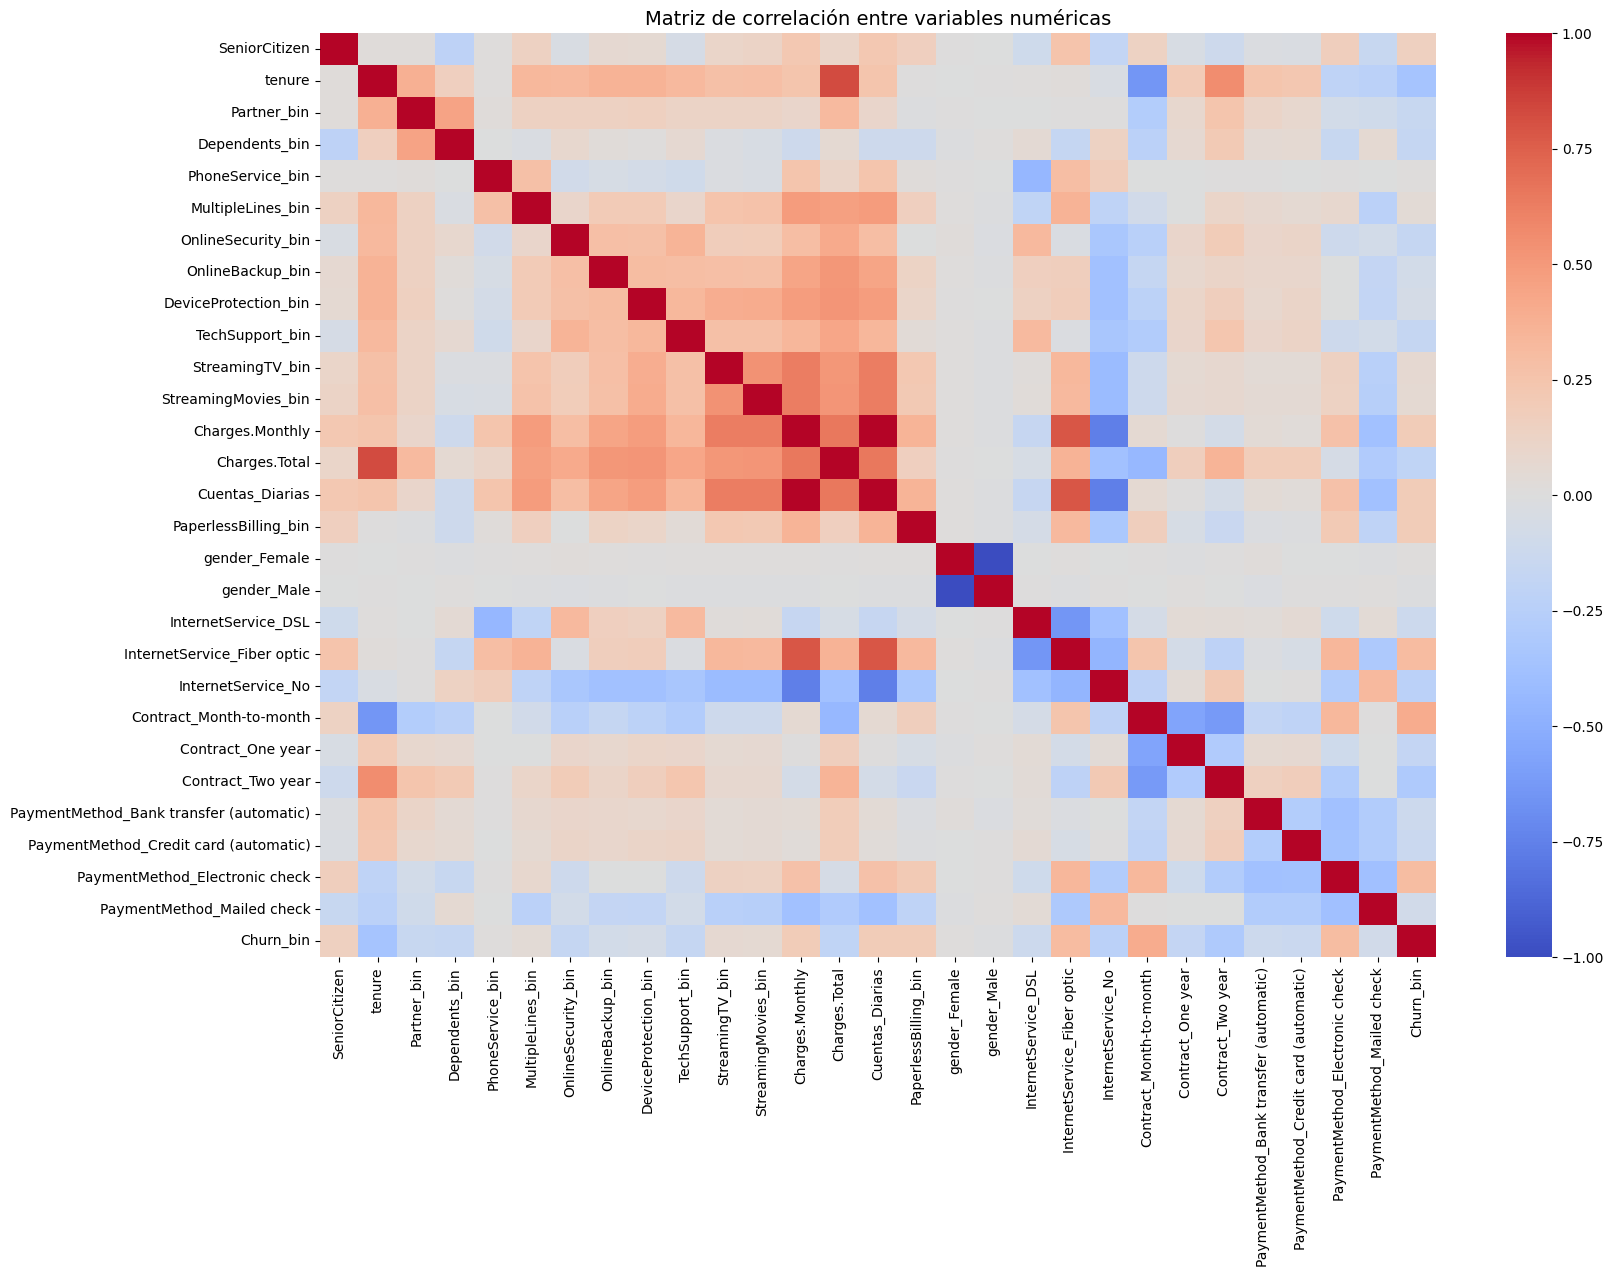

In [26]:
# Importamos librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño de la figura para que se vea mejor
plt.figure(figsize=(18, 12))

# Dibujamos el mapa de calor de correlaciones
# center=0 ayuda a distinguir mejor correlaciones positivas y negativas
sns.heatmap(
    matriz_corr,
    cmap="coolwarm",
    center=0
)

# Agregamos título al gráfico
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)

# Mostramos el gráfico
plt.show()

In [27]:
# Extraemos solo la correlación de cada variable con la variable objetivo Churn_bin
# drop("Churn_bin") elimina la autocorrelación de la propia variable objetivo
corr_con_churn = matriz_corr["Churn_bin"].drop("Churn_bin")

# Ordenamos de mayor a menor correlación
corr_con_churn = corr_con_churn.sort_values(ascending=False)

# Mostramos el resultado
corr_con_churn

,Churn_bin
Contract_Month-to-month,0.405103
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling_bin,0.191825
SeniorCitizen,0.150889
StreamingTV_bin,0.063228
StreamingMovies_bin,0.061382
MultipleLines_bin,0.040102


In [28]:
# Construimos una tabla resumen con:
# - correlación directa con Churn_bin
# - correlación absoluta, para ver qué variables tienen mayor fuerza de relación
tabla_corr_churn = pd.DataFrame({
    "Correlación con Churn_bin": corr_con_churn,
    "Correlación absoluta": corr_con_churn.abs()
})

# Ordenamos por correlación absoluta de mayor a menor
tabla_corr_churn = tabla_corr_churn.sort_values(
    by="Correlación absoluta",
    ascending=False
)

# Mostramos la tabla resumen
tabla_corr_churn

,Correlación con Churn_bin,Correlación absoluta
Contract_Month-to-month,0.405103,0.405103
tenure,-0.352229,0.352229
InternetService_Fiber optic,0.308020,0.308020
Contract_Two year,-0.302253,0.302253
PaymentMethod_Electronic check,0.301919,0.301919
InternetService_No,-0.227890,0.227890
Charges.Total,-0.198324,0.198324
Charges.Monthly,0.193356,0.193356
Cuentas_Diarias,0.193356,0.193356
PaperlessBilling_bin,0.191825,0.191825


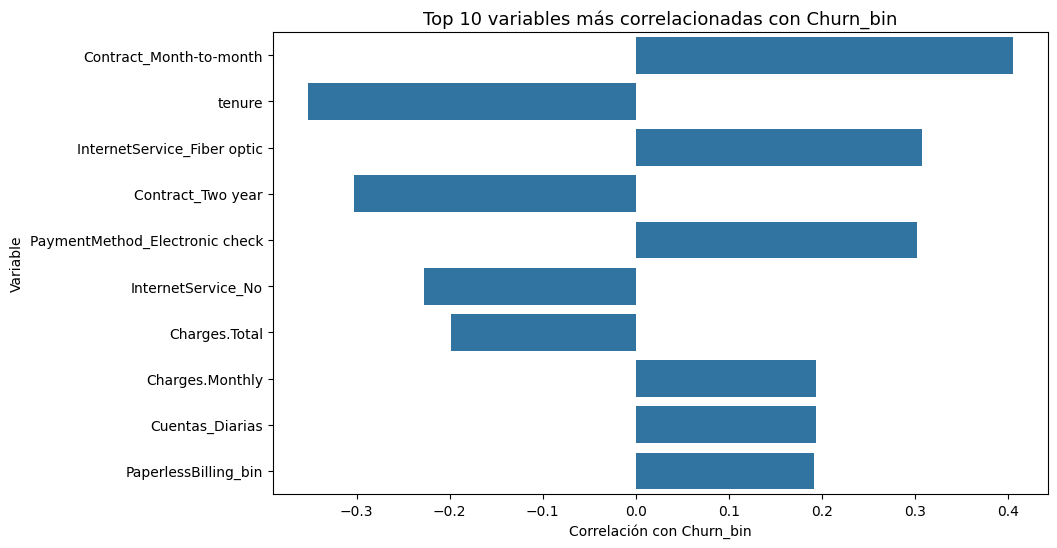

In [29]:
# Seleccionamos las 10 variables con mayor correlación absoluta con Churn_bin
top_corr = tabla_corr_churn.head(10).reset_index()

# Renombramos la columna del índice para que el gráfico quede más claro
top_corr = top_corr.rename(columns={"index": "Variable"})

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos un gráfico de barras horizontal
sns.barplot(
    data=top_corr,
    y="Variable",
    x="Correlación con Churn_bin"
)

# Agregamos título y etiquetas
plt.title("Top 10 variables más correlacionadas con Churn_bin", fontsize=13)
plt.xlabel("Correlación con Churn_bin")
plt.ylabel("Variable")

# Mostramos el gráfico
plt.show()

In [30]:
# Definimos un umbral exploratorio de correlación absoluta
# Este umbral no elimina variables automáticamente, solo ayuda a destacar candidatas
umbral = 0.10

# Seleccionamos las variables cuya correlación absoluta con Churn_bin
# sea igual o mayor al umbral definido
variables_candidatas = tabla_corr_churn[
    tabla_corr_churn["Correlación absoluta"] >= umbral
].index.tolist()

# Mostramos la lista de variables candidatas
variables_candidatas

['Contract_Month-to-month',
 'tenure',
 'InternetService_Fiber optic',
 'Contract_Two year',
 'PaymentMethod_Electronic check',
 'InternetService_No',
 'Charges.Total',
 'Charges.Monthly',
 'Cuentas_Diarias',
 'PaperlessBilling_bin',
 'Contract_One year',
 'OnlineSecurity_bin',
 'TechSupport_bin',
 'Dependents_bin',
 'SeniorCitizen',
 'Partner_bin',
 'PaymentMethod_Credit card (automatic)',
 'InternetService_DSL',
 'PaymentMethod_Bank transfer (automatic)']

Interpretación del análisis de correlación:

El análisis de correlación mostró que las variables más asociadas positivamente con la cancelación fueron Contract_Month-to-month, InternetService_Fiber optic y PaymentMethod_Electronic check, lo que indica que estos perfiles presentan mayor probabilidad de churn. En cambio, variables como tenure, Contract_Two year y Contract_One year presentaron correlaciones negativas relevantes, sugiriendo que una mayor permanencia y contratos de largo plazo se asocian con menor evasión.
También se observó que Charges.Monthly y Cuentas_Diarias presentan la misma señal, lo cual es coherente porque Cuentas_Diarias deriva directamente de Charges.Monthly. Por otra parte, las variables de género mostraron correlaciones cercanas a cero, por lo que no parecen tener un peso importante en la cancelación.
En conjunto, este análisis permite identificar variables candidatas para el modelo predictivo, aunque la correlación no se utilizará como criterio único de eliminación, sino como apoyo para la selección e interpretación.

# 8. Análisis Dirigido
Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [31]:
# Creamos un DataFrame auxiliar solo para este análisis visual
# Usamos las columnas originales para que los gráficos sean más claros de interpretar
df_dirigido = df[["Churn", "tenure", "Charges.Total"]].copy()

# Mostramos las primeras filas para validar que las columnas correctas están presentes
df_dirigido.head()

,Churn,tenure,Charges.Total
0,No,9,593.30
1,No,9,542.40
2,Yes,4,280.85
3,Yes,13,1237.85
4,Yes,3,267.40


In [32]:
# Agrupamos por la variable Churn para comparar estadísticas básicas
# Esto nos permite ver diferencias de promedio, mediana y dispersión
df_dirigido.groupby("Churn")[["tenure", "Charges.Total"]].describe()

tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      Charges.Total                                                    \
              count         mean          std    min    25%       50%   
Churn                                                                   
No           5174.0  2549.911442  2329.954215   0.00  572.9  1679.525   
Yes          1869.0  1531.796094  1890.822994  18.85  134.5   703.550   

                         
           75%      max  
Churn                    
No     4262.85  8672.45  
Yes    2331.30  8684.80

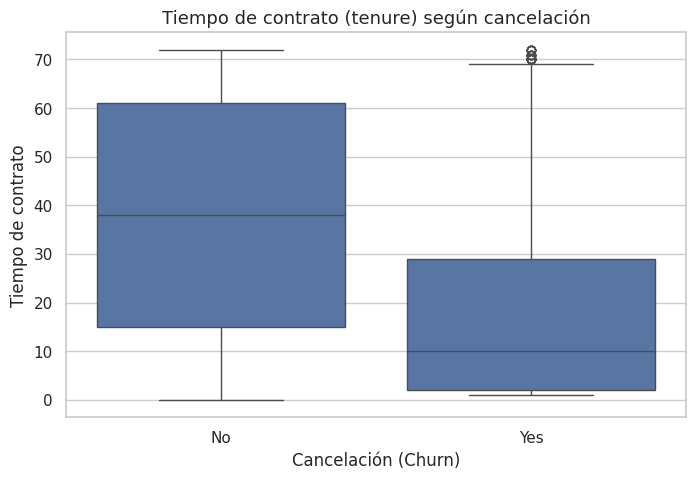

In [33]:
# Importamos librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# Creamos un boxplot para comparar tenure entre clientes que cancelaron y los que no
# x = categoría de churn
# y = tiempo de permanencia (tenure)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_dirigido, x="Churn", y="tenure")

# Agregamos título y etiquetas para que el gráfico sea más entendible
plt.title("Tiempo de contrato (tenure) según cancelación", fontsize=13)
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Tiempo de contrato")

# Mostramos el gráfico
plt.show()

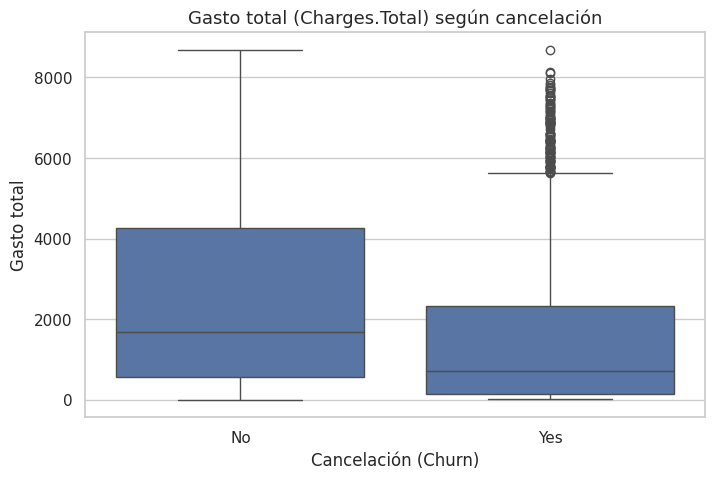

In [34]:
# Creamos un boxplot para comparar el gasto total entre clientes que cancelaron y los que no
# x = categoría de churn
# y = gasto total acumulado
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_dirigido, x="Churn", y="Charges.Total")

# Agregamos título y etiquetas
plt.title("Gasto total (Charges.Total) según cancelación", fontsize=13)
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Gasto total")

# Mostramos el gráfico
plt.show()

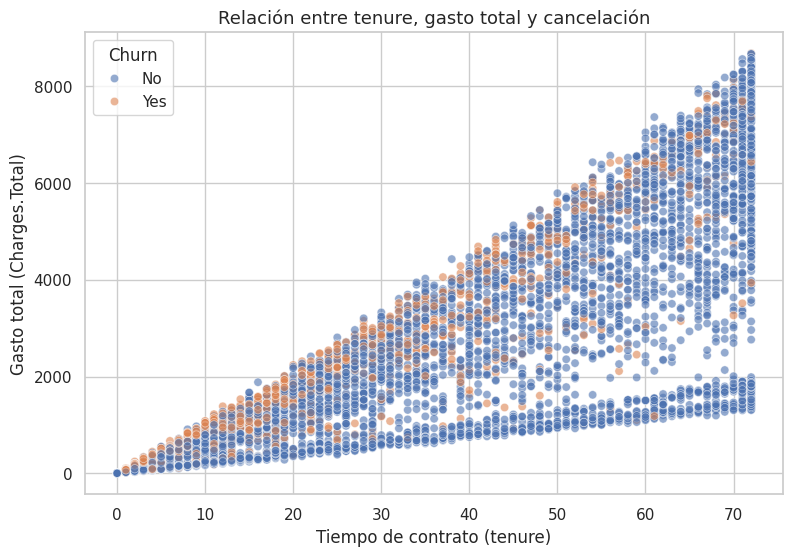

In [35]:
# Creamos un gráfico de dispersión para ver la relación conjunta entre:
# - tiempo de contrato (tenure)
# - gasto total (Charges.Total)
# Además, coloreamos por churn para distinguir los grupos visualmente
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_dirigido,
    x="tenure",
    y="Charges.Total",
    hue="Churn",
    alpha=0.6
)

# Agregamos título y etiquetas
plt.title("Relación entre tenure, gasto total y cancelación", fontsize=13)
plt.xlabel("Tiempo de contrato (tenure)")
plt.ylabel("Gasto total (Charges.Total)")

# Mostramos el gráfico
plt.show()

In [36]:
# Calculamos promedios por grupo para reforzar la interpretación visual
# Esto ayuda a acompañar los boxplots con valores concretos
resumen_dirigido = df_dirigido.groupby("Churn")[["tenure", "Charges.Total"]].mean().round(2)

# Mostramos el resumen
resumen_dirigido

,tenure,Charges.Total
Churn,,
No,37.57,2549.91
Yes,17.98,1531.80


El análisis dirigido muestra que los clientes que cancelan tienden a tener una menor antigüedad en la empresa, ya que su tenure promedio es considerablemente más bajo que el de los clientes que permanecen activos. Esto sugiere que la cancelación ocurre con mayor frecuencia en etapas tempranas de la relación con Telecom X.

En cuanto al gasto total (Charges.Total), los clientes que no cancelan presentan valores más altos que los clientes con churn. Esto es consistente con el hecho de que Charges.Total es una variable acumulada: mientras más tiempo permanece un cliente, mayor es el gasto total que alcanza a acumular.

El gráfico de dispersión refuerza esta idea, mostrando una relación positiva entre tenure y Charges.Total, y evidenciando que muchos clientes que cancelan se concentran en zonas de menor permanencia y menor gasto acumulado.

# 🤖 Modelado Predictivo
# 9. Separación de Datos
Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [37]:
# Importamos train_test_split desde scikit-learn
# Esta función nos permite dividir los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

In [39]:
# Dividimos los datos en entrenamiento y prueba
# X contiene las variables predictoras ya preparadas
# y contiene la variable objetivo (Churn_bin)

# test_size=0.30 significa:
# - 70% de los datos para entrenamiento
# - 30% de los datos para prueba

# random_state=42 permite reproducir la misma división si volvemos a ejecutar el código
# stratify=y mantiene la misma proporción de churn en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [40]:
# Mostramos el tamaño de los conjuntos resultantes
# Esto nos ayuda a verificar que la división se realizó correctamente
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (4930, 28)
Dimensiones de X_test: (2113, 28)
Dimensiones de y_train: (4930,)
Dimensiones de y_test: (2113,)


In [41]:
# Revisamos la proporción de la variable objetivo en entrenamiento
# normalize=True entrega proporciones en vez de conteos absolutos
print("Proporción de churn en y_train:")
print(y_train.value_counts(normalize=True).round(4))

# Revisamos la proporción de la variable objetivo en prueba
print("\nProporción de churn en y_test:")
print(y_test.value_counts(normalize=True).round(4))

Proporción de churn en y_train:
Churn_bin
0    0.7347
1    0.2653
Name: proportion, dtype: float64

Proporción de churn en y_test:
Churn_bin
0    0.7345
1    0.2655
Name: proportion, dtype: float64


In [42]:
# Construimos una tabla comparativa para ver si la distribución de clases
# se mantuvo parecida entre entrenamiento y prueba
tabla_split = pd.DataFrame({
    "Train (%)": (y_train.value_counts(normalize=True) * 100).round(2),
    "Test (%)": (y_test.value_counts(normalize=True) * 100).round(2)
})

# Renombramos los índices para que la tabla sea más entendible
tabla_split.index = ["No canceló (0)", "Sí canceló (1)"]

# Mostramos la tabla resumen
tabla_split

,Train (%),Test (%)
No canceló (0),73.47,73.45
Sí canceló (1),26.53,26.55


Conclusión del paso 9:

Se dividió correctamente el conjunto de datos en entrenamiento y prueba utilizando una proporción 70/30. Además, se aplicó stratify=y para conservar la distribución de la variable objetivo en ambos subconjuntos. Los resultados muestran que la proporción de clientes que cancelaron y no cancelaron se mantuvo prácticamente igual entre entrenamiento y prueba, dejando la base lista para el modelado predictivo.

# 10. Creación de Modelos
Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [43]:
# Importamos los modelos de clasificación que vamos a utilizar
# DecisionTreeClassifier crea un árbol de decisión simple
# RandomForestClassifier crea un conjunto de árboles y combina sus resultados
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [44]:
# Creamos el modelo de Árbol de Decisión
# random_state=42 permite reproducir el mismo resultado si volvemos a ejecutar el código
modelo_arbol = DecisionTreeClassifier(random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
# X_train contiene las variables predictoras
# y_train contiene la variable objetivo
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [45]:
# Creamos el modelo de Random Forest
# Este modelo combina varios árboles de decisión para mejorar la estabilidad y el rendimiento
# random_state=42 permite reproducibilidad
modelo_rf = RandomForestClassifier(random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
# Generamos las predicciones del Árbol de Decisión sobre el conjunto de prueba
y_pred_arbol = modelo_arbol.predict(X_test)

# Generamos las predicciones del Random Forest sobre el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test)

In [47]:
# Mostramos las primeras 10 predicciones de cada modelo
# Esto sirve para validar que ambos modelos ya están funcionando
print("Primeras 10 predicciones - Árbol de Decisión:")
print(y_pred_arbol[:10])

print("\nPrimeras 10 predicciones - Random Forest:")
print(y_pred_rf[:10])

Primeras 10 predicciones - Árbol de Decisión:
[0 0 0 0 0 0 0 0 0 1]

Primeras 10 predicciones - Random Forest:
[0 0 1 0 0 0 0 0 1 1]


In [48]:
# Mostramos una confirmación simple de que ambos modelos ya fueron creados y entrenados
print("Modelo 1 entrenado:", modelo_arbol)
print("Modelo 2 entrenado:", modelo_rf)

Modelo 1 entrenado: DecisionTreeClassifier(random_state=42)
Modelo 2 entrenado: RandomForestClassifier(random_state=42)


Conclusión del paso 10:

Se crearon y entrenaron correctamente dos modelos de clasificación: un Árbol de Decisión y un Random Forest. Ambos modelos pudieron ajustarse sin problemas al conjunto de entrenamiento y generar predicciones sobre el conjunto de prueba. En esta etapa se confirma que el pipeline de modelado está funcionando correctamente, quedando pendiente la evaluación comparativa de desempeño.

# 11. Evaluación de los Modelos
Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [49]:
# Importamos las métricas de evaluación para modelos de clasificación
# Estas métricas nos permitirán comparar el rendimiento de ambos modelos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [50]:
# Generamos predicciones del Árbol de Decisión sobre entrenamiento y prueba
# Esto nos permitirá comparar si el modelo generaliza bien o si sobreajusta
y_train_pred_arbol = modelo_arbol.predict(X_train)
y_test_pred_arbol = modelo_arbol.predict(X_test)

# Generamos predicciones del Random Forest sobre entrenamiento y prueba
y_train_pred_rf = modelo_rf.predict(X_train)
y_test_pred_rf = modelo_rf.predict(X_test)

In [51]:
# Creamos una función para calcular las métricas principales de clasificación
# Esto evita repetir el mismo código para cada modelo
def calcular_metricas(y_real, y_pred):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1-score": f1_score(y_real, y_pred, zero_division=0)
    }

In [52]:
# Calculamos las métricas del Árbol de Decisión en entrenamiento y prueba
metricas_arbol_train = calcular_metricas(y_train, y_train_pred_arbol)
metricas_arbol_test = calcular_metricas(y_test, y_test_pred_arbol)

# Calculamos las métricas del Random Forest en entrenamiento y prueba
metricas_rf_train = calcular_metricas(y_train, y_train_pred_rf)
metricas_rf_test = calcular_metricas(y_test, y_test_pred_rf)

In [54]:
# Construimos una tabla resumen para comparar ambos modelos
# Incluimos resultados en entrenamiento y en prueba
tabla_metricas = pd.DataFrame({
    "Árbol - Train": metricas_arbol_train,
    "Árbol - Test": metricas_arbol_test,
    "Random Forest - Train": metricas_rf_train,
    "Random Forest - Test": metricas_rf_test
}).round(4)

# Mostramos la tabla comparativa
tabla_metricas

,Árbol - Train,Árbol - Test,Random Forest - Train,Random Forest - Test
Accuracy,0.9978,0.7326,0.9978,0.7814
Precision,0.9992,0.4966,0.9954,0.6083
Recall,0.9924,0.5152,0.9962,0.4955
F1-score,0.9958,0.5057,0.9958,0.5462


In [55]:
# Mostramos el reporte de clasificación del Árbol de Decisión en prueba
# Esto entrega precisión, recall y F1-score por clase
print("Classification Report - Árbol de Decisión")
print(classification_report(y_test, y_test_pred_arbol, zero_division=0))

Classification Report - Árbol de Decisión
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1552
           1       0.50      0.52      0.51       561

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.74      0.73      0.73      2113



In [56]:
# Mostramos el reporte de clasificación del Random Forest en prueba
print("Classification Report - Random Forest")
print(classification_report(y_test, y_test_pred_rf, zero_division=0))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1552
           1       0.61      0.50      0.55       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



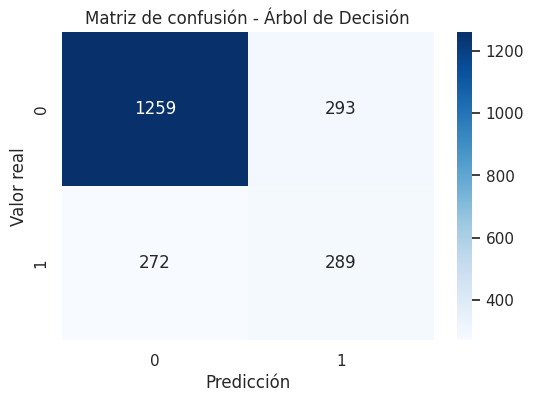

In [57]:
# Calculamos la matriz de confusión del Árbol de Decisión
cm_arbol = confusion_matrix(y_test, y_test_pred_arbol)

# La visualizamos con mapa de calor para que sea más fácil de interpretar
plt.figure(figsize=(6, 4))
sns.heatmap(cm_arbol, annot=True, fmt="d", cmap="Blues")

# Agregamos títulos y etiquetas
plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

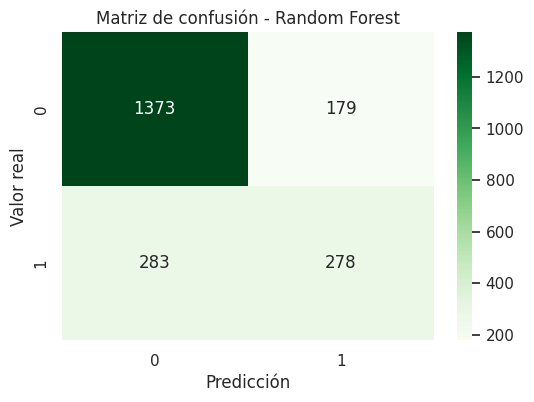

In [58]:
# Calculamos la matriz de confusión del Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

# La visualizamos con mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

# Agregamos títulos y etiquetas
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [59]:
# Comparamos específicamente Accuracy y F1-score entre train y test
# Esto ayuda a detectar si algún modelo está sobreajustando
comparacion_ajuste = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest"],
    "Accuracy Train": [
        metricas_arbol_train["Accuracy"],
        metricas_rf_train["Accuracy"]
    ],
    "Accuracy Test": [
        metricas_arbol_test["Accuracy"],
        metricas_rf_test["Accuracy"]
    ],
    "F1 Train": [
        metricas_arbol_train["F1-score"],
        metricas_rf_train["F1-score"]
    ],
    "F1 Test": [
        metricas_arbol_test["F1-score"],
        metricas_rf_test["F1-score"]
    ]
}).round(4)

# Mostramos la tabla
comparacion_ajuste

,Modelo,Accuracy Train,Accuracy Test,F1 Train,F1 Test
0,Árbol de Decisión,0.9978,0.7326,0.9958,0.5057
1,Random Forest,0.9978,0.7814,0.9958,0.5462


Interpretación de la evaluación de modelos

Se compararon dos modelos de clasificación: un Árbol de Decisión y un Random Forest. En el conjunto de prueba, el Random Forest presentó el mejor desempeño general, alcanzando mayor accuracy, precision y F1-score que el Árbol de Decisión. Aunque el Árbol obtuvo un recall ligeramente superior para la clase de cancelación, su desempeño global fue inferior.

Al comparar entrenamiento y prueba, ambos modelos mostraron señales claras de overfitting, ya que sus métricas en entrenamiento fueron extremadamente altas, mientras que en prueba disminuyeron de forma importante. Este comportamiento sugiere que los modelos aprendieron en exceso los patrones del conjunto de entrenamiento y perdieron capacidad de generalización.

Entre ambos, el Random Forest resultó más robusto, por lo que se considera el mejor modelo base en esta etapa. Sin embargo, todavía existe margen de mejora mediante ajuste de hiperparámetros, control de complejidad y estrategias para manejar el desbalance de clases.

# 📋 Interpretación y Conclusiones

# 12. Análisis de la Importancia de las Variables

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).




In [60]:
# Extraemos la importancia de cada variable desde el modelo Random Forest
# feature_importances_ devuelve un valor numérico que indica cuánto aportó
# cada variable a las decisiones del modelo
importancias_rf = modelo_rf.feature_importances_

# Creamos una tabla con:
# - nombre de la variable
# - importancia calculada por el modelo
tabla_importancia_rf = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias_rf
})

# Ordenamos de mayor a menor importancia
tabla_importancia_rf = tabla_importancia_rf.sort_values(
    by="Importancia",
    ascending=False
)

# Mostramos la tabla completa
tabla_importancia_rf

,Variable,Importancia
13,Charges.Total,0.158723
1,tenure,0.137533
14,Cuentas_Diarias,0.128088
12,Charges.Monthly,0.126275
21,Contract_Month-to-month,0.063759
19,InternetService_Fiber optic,0.035669
26,PaymentMethod_Electronic check,0.029708
15,PaperlessBilling_bin,0.023967
23,Contract_Two year,0.022793
2,Partner_bin,0.020466


In [61]:
# Seleccionamos las 10 variables más importantes del modelo
top_10_importancia_rf = tabla_importancia_rf.head(10)

# Mostramos la tabla resumida
top_10_importancia_rf

,Variable,Importancia
13,Charges.Total,0.158723
1,tenure,0.137533
14,Cuentas_Diarias,0.128088
12,Charges.Monthly,0.126275
21,Contract_Month-to-month,0.063759
19,InternetService_Fiber optic,0.035669
26,PaymentMethod_Electronic check,0.029708
15,PaperlessBilling_bin,0.023967
23,Contract_Two year,0.022793
2,Partner_bin,0.020466


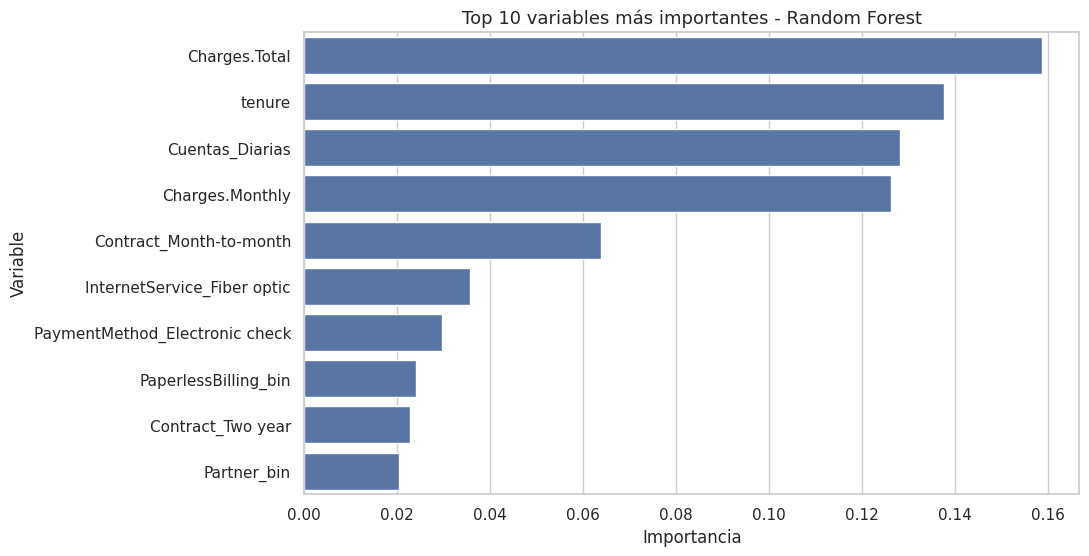

In [62]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos un gráfico de barras horizontal para visualizar mejor las importancias
sns.barplot(
    data=top_10_importancia_rf,
    y="Variable",
    x="Importancia"
)

# Agregamos título y etiquetas
plt.title("Top 10 variables más importantes - Random Forest", fontsize=13)
plt.xlabel("Importancia")
plt.ylabel("Variable")

# Mostramos el gráfico
plt.show()

In [63]:
# Convertimos la importancia a porcentaje para que sea más fácil de interpretar
tabla_importancia_rf["Importancia (%)"] = (
    tabla_importancia_rf["Importancia"] /
    tabla_importancia_rf["Importancia"].sum()
) * 100

# Redondeamos para que la lectura sea más clara
tabla_importancia_rf["Importancia (%)"] = tabla_importancia_rf["Importancia (%)"].round(2)

# Mostramos nuevamente la tabla
tabla_importancia_rf

,Variable,Importancia,Importancia (%)
13,Charges.Total,0.158723,15.87
1,tenure,0.137533,13.75
14,Cuentas_Diarias,0.128088,12.81
12,Charges.Monthly,0.126275,12.63
21,Contract_Month-to-month,0.063759,6.38
19,InternetService_Fiber optic,0.035669,3.57
26,PaymentMethod_Electronic check,0.029708,2.97
15,PaperlessBilling_bin,0.023967,2.40
23,Contract_Two year,0.022793,2.28
2,Partner_bin,0.020466,2.05


In [64]:
# Calculamos la importancia acumulada
# Esto ayuda a ver cuánto explican en conjunto las variables principales
tabla_importancia_rf["Importancia acumulada (%)"] = tabla_importancia_rf["Importancia (%)"].cumsum().round(2)

# Mostramos las primeras 15 variables para revisar acumulación
tabla_importancia_rf.head(15)

,Variable,Importancia,Importancia (%),Importancia acumulada (%)
13,Charges.Total,0.158723,15.87,15.87
1,tenure,0.137533,13.75,29.62
14,Cuentas_Diarias,0.128088,12.81,42.43
12,Charges.Monthly,0.126275,12.63,55.06
21,Contract_Month-to-month,0.063759,6.38,61.44
19,InternetService_Fiber optic,0.035669,3.57,65.01
26,PaymentMethod_Electronic check,0.029708,2.97,67.98
15,PaperlessBilling_bin,0.023967,2.40,70.38
23,Contract_Two year,0.022793,2.28,72.66
2,Partner_bin,0.020466,2.05,74.71


In [65]:
# Extraemos también la importancia del Árbol de Decisión
# Esto sirve como comparación complementaria, aunque el modelo principal sea Random Forest
importancias_arbol = modelo_arbol.feature_importances_

# Creamos una tabla equivalente para el Árbol de Decisión
tabla_importancia_arbol = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias_arbol
}).sort_values(by="Importancia", ascending=False)

# Mostramos las 10 variables más importantes del árbol
tabla_importancia_arbol.head(10)

,Variable,Importancia
13,Charges.Total,0.185387
21,Contract_Month-to-month,0.171616
14,Cuentas_Diarias,0.128018
1,tenure,0.126590
12,Charges.Monthly,0.093705
19,InternetService_Fiber optic,0.046268
15,PaperlessBilling_bin,0.022145
26,PaymentMethod_Electronic check,0.021951
5,MultipleLines_bin,0.018355
3,Dependents_bin,0.017885


Conclusión del análisis de importancia de variables:

A partir del modelo Random Forest, se identificó que las variables más relevantes para predecir la cancelación de clientes fueron Charges.Total, tenure, Cuentas_Diarias, Charges.Monthly y Contract_Month-to-month. Esto indica que la permanencia del cliente, el gasto acumulado, el nivel de cobro y el tipo de contrato son factores clave en la predicción del churn. También destacaron variables como InternetService_Fiber optic y PaymentMethod_Electronic check, reforzando hallazgos observados previamente en el análisis exploratorio y de correlación.
En conjunto, estos resultados sugieren que el riesgo de cancelación está fuertemente asociado a clientes con menor antigüedad, contratos más flexibles, ciertos métodos de pago y características específicas del servicio contratado.

# 13. Conclusión
Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

# Conclusión Final
## 1. Resumen general del análisis

A partir del proceso completo de preparación de datos, análisis exploratorio, selección de variables y modelado predictivo, fue posible identificar patrones claros asociados a la cancelación de clientes en Telecom X. El análisis mostró que la evasión no se distribuye al azar, sino que se concentra en ciertos perfiles específicos de clientes, especialmente aquellos con menor permanencia, contratos más flexibles y determinadas características de servicio y pago.

La variable objetivo presentó una distribución de 73.46% de clientes que permanecen y 26.54% de clientes que cancelan, lo que indica un desbalance moderado entre clases. Esto fue considerado en la interpretación de métricas y en la evaluación de los modelos.

## 2. Desempeño de los modelos predictivos

Se entrenaron dos modelos de clasificación:

*   Árbol de Decisión
*   Random Forest

Al comparar sus métricas en el conjunto de prueba, el Random Forest mostró el mejor desempeño general.

Resultados principales en prueba

Árbol de Decisión

Accuracy: 0.7326

Precision: 0.4966

Recall: 0.5152

F1-score: 0.5057

Random Forest

Accuracy: 0.7814

Precision: 0.6083

Recall: 0.4955

F1-score: 0.5462

Interpretación

El Random Forest fue el modelo más sólido, ya que obtuvo mejor accuracy, precision y F1-score. Aunque el Árbol de Decisión logró un recall levemente superior, su desempeño global fue menor. Por ello, el Random Forest se considera el modelo base más adecuado en esta etapa.

Sin embargo, ambos modelos mostraron señales de overfitting, ya que en entrenamiento alcanzaron métricas extremadamente altas (accuracy cercana a 0.998 y F1-score cercana a 0.996), mientras que en prueba el rendimiento disminuyó de manera importante. Esto sugiere que todavía existe margen de mejora mediante ajuste de hiperparámetros, control de complejidad y técnicas complementarias de validación.

## 3. Factores que más influyen en la cancelación

El análisis de correlación, el análisis dirigido y la importancia de variables del Random Forest permitieron identificar los factores más relevantes asociados al churn.

Principales factores de mayor riesgo

Los resultados muestran que la cancelación está más asociada a clientes con las siguientes características:

Contrato mes a mes (Contract_Month-to-month)

Servicio de internet de fibra óptica (InternetService_Fiber optic)

Método de pago por electronic check (PaymentMethod_Electronic check)

Cobros mensuales más altos (Charges.Monthly)

Facturación sin papel (PaperlessBilling_bin)

Menor tiempo de permanencia (tenure bajo)

Factores asociados a menor cancelación

También se identificaron variables que parecen actuar como factores de estabilidad o permanencia:

Mayor antigüedad del cliente (tenure)

Contratos de uno o dos años (Contract_One year, Contract_Two year)

Tener soporte técnico (TechSupport_bin)

Tener seguridad online (OnlineSecurity_bin)

Tener pareja o dependientes (Partner_bin, Dependents_bin)

# 4. Hallazgos más importantes del negocio
a) La permanencia del cliente es clave

Uno de los resultados más consistentes del análisis fue la fuerte relación entre churn y antigüedad. Los clientes que cancelan presentan una permanencia promedio de 17.98 meses, mientras que los clientes que permanecen alcanzan un promedio de 37.57 meses. Esto sugiere que existe un período crítico en los primeros meses de relación con la empresa.

b) El tipo de contrato es uno de los factores más relevantes

El contrato mes a mes fue una de las variables más asociadas a la cancelación, mientras que los contratos de mayor duración se relacionaron con una menor probabilidad de churn. Esto indica que la estabilidad contractual es un factor importante para la retención.

c) El método de pago también influye

El uso de electronic check apareció tanto en el análisis exploratorio como en correlación e importancia de variables como un perfil de mayor riesgo. Esto puede reflejar fricción en el proceso de pago, menor compromiso con el servicio o una experiencia de cobro menos estable.

d) El servicio de fibra óptica merece atención especial

La categoría InternetService_Fiber optic mostró una asociación importante con la cancelación. Esto no implica necesariamente causalidad directa, pero sí sugiere que este grupo concentra clientes con mayor riesgo de evasión.

e) El gasto y la permanencia están conectados

Las variables Charges.Total, Charges.Monthly y Cuentas_Diarias aparecieron entre las más importantes. Esto indica que el componente económico sí influye, aunque debe interpretarse con cautela, ya que algunas de estas variables están relacionadas entre sí.

# 5. Variables más relevantes según el Random Forest

El modelo Random Forest destacó principalmente las siguientes variables:

Charges.Total

tenure

Cuentas_Diarias

Charges.Monthly

Contract_Month-to-month

InternetService_Fiber optic

PaymentMethod_Electronic check

PaperlessBilling_bin

Contract_Two year

Partner_bin

En conjunto, estas variables resumen de manera bastante clara el fenómeno de cancelación: permanencia, estructura de cobro, modalidad contractual, características del servicio y perfil del cliente.

# 6. Estrategias de retención propuestas

Con base en los resultados obtenidos, se proponen las siguientes estrategias de retención:

1. Retención temprana de clientes nuevos

Dado que el churn se concentra en clientes con menor antigüedad, se recomienda:

reforzar onboarding y acompañamiento en los primeros meses;

implementar alertas tempranas para clientes recientes con señales de riesgo;

realizar contactos preventivos antes de los primeros puntos críticos de abandono.

2. Migración desde contratos mes a mes

Se recomienda impulsar campañas orientadas a que clientes de alto riesgo pasen de contrato mensual a planes de mayor duración, por ejemplo mediante:

descuentos por permanencia;

beneficios por migración a planes anuales;

promociones ligadas a compromiso de plazo.

3. Revisión del proceso de pago en electronic check

Como este método de pago aparece muy asociado a churn, se sugiere:

incentivar métodos automáticos;

revisar problemas de cobranza o fricción operativa;

simplificar mensajes y recordatorios de pago.

4. Intervención focalizada sobre clientes de fibra óptica

El grupo con fibra óptica merece seguimiento especial. Sería recomendable:

auditar calidad del servicio y soporte;

revisar si existen problemas recurrentes de experiencia;

diseñar campañas específicas de fidelización para este segmento.

5. Promover servicios de valor agregado

Variables como TechSupport_bin y OnlineSecurity_bin se relacionan con menor churn. Esto sugiere que ofrecer o fortalecer servicios complementarios puede mejorar la permanencia.

# 7. Conclusión final

En síntesis, la cancelación en Telecom X está fuertemente asociada a clientes con baja permanencia, contratos mes a mes, ciertos métodos de pago y características específicas del servicio contratado, especialmente la fibra óptica. El modelo Random Forest logró el mejor desempeño general para predecir la evasión, aunque todavía presenta oportunidades de mejora por sobreajuste.

Los hallazgos permiten concluir que la empresa no solo puede identificar clientes con mayor riesgo de cancelación, sino también actuar estratégicamente sobre los principales factores que explican ese comportamiento. En particular, las acciones de retención deberían enfocarse en la permanencia temprana, la mejora de experiencia en segmentos de riesgo y la reducción de fricción en pago y servicio.